## Exercise 2: Semantic Segmentation (40 Points)

### Introduction
In this exercise, you will train a Random Forest (RF) classifier to assign class labels to image segments based on extracted features. To do this, you will build upon the methods developed in the previous exercise to generate image segments and compute their corresponding feature vectors. Using this feature data along with the provided ground-truth labels, you will train the RF classifier and evaluate its performance using appropriate metrics. 

**Note:** Your submission will be evaluated automatically, so it is essential to use the predefined parameter names for each task. Please keep the free text tasks relatively short. 

**Important:** As we are working with high-resolution image data, inefficient code can result in significantly longer execution times. It is strongly recommended to use vectorized operations instead of for-loops whenever possible. The autograding tool allows a maximum execution time of **10 minutes per cell**, so ensure your code runs well within this limit. With vectorized operations, all cells should execute within seconds.

**Data:** Within this docker image are only the tiles `5_10`, `5_11` and `5_12` available.


Execute the cell below to import all necessary libraries for this exercise.

**Note:** The methods implemented in the last exercise are provided in the script `utils.py` and imported in the cell below. 

In [1]:
# copy utils.py from shared folder to current working directory
!cp '/home/jovyan/work/__shared/utils.py' 'utils.py'
# Required Libraries
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from skimage import io
from skimage.segmentation import mark_boundaries
from skimage.transform import rescale

from time import time

# Custom helpers from Lab 1
from utils import rgb2index, index2rgb, slic_segmentation, mean_segments, majority_vote_segments


### Do not change the parameter definition `label_def` and `label_mapping` below.
label_def = np.array([[255, 255, 255], [255, 255, 0], [0, 0, 255], [0, 255, 255], [0, 255, 0], [255, 0, 0]])
label_mapping = {0: 'Impervious surfaces', 1: 'Building', 2: 'Low vegetation', 3: 'Tree', 4: 'Car', 5: 'Clutter/Background'}
train_tile_name = '5_10'
valid_tile_name = '5_11'
test_tile_name = '5_12'

%matplotlib inline

### Data Loading
As previously announced, we are building upon the state from the last exercise. To ensure everyone is on the same page, the relevant methods from the last exercise have been provided to you in the utils.py. In that file, you will find all functions we previously defined in the Jupyter Notebook. Go and have a look at the implementations and compare them to your solution from Lab 1.

The following cell will load the data similar to Lab 1 with rescaling.

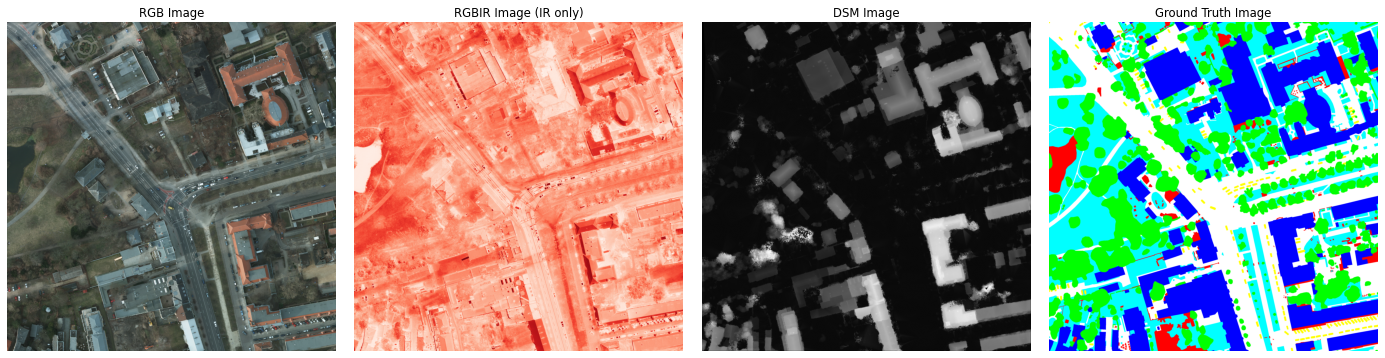

In [2]:
## Do not change the code below

data_path = '/home/jovyan/work/__shared'

train_dsm_filename = f"{data_path}/1_DSM_normalisation/dsm_potsdam_0{train_tile_name}_normalized_lastools.jpg"
train_rgb_filename = f"{data_path}/2_Ortho_RGB/top_potsdam_{train_tile_name}_RGB.tif"
train_rgbir_filename = f"{data_path}/4_Ortho_RGBIR/top_potsdam_{train_tile_name}_RGBIR.tif"
train_gt_filename = f"{data_path}/5_Labels_all/top_potsdam_{train_tile_name}_label.tif"

img_rgb = io.imread(train_rgb_filename)
img_ir  = io.imread(train_rgbir_filename)[...,3]
dsm     = io.imread(train_dsm_filename)
img_gt  = io.imread(train_gt_filename)

img_rgb = rescale(img_rgb, (0.5,0.5,1), order = 1, preserve_range=True).astype(np.uint8)
img_ir  = rescale(img_ir,  (0.5),       order = 1, preserve_range=True).astype(np.uint8)
dsm     = rescale(dsm,     (0.5),       order = 0, preserve_range=True).astype(np.uint8)
img_gt  = rescale(img_gt,  (0.5,0.5,1), order = 0, preserve_range=True).astype(np.uint8)
                                    
fig, axs = plt.subplots(1, 4, figsize=(20, 5), dpi=70)
axs[0].imshow(img_rgb)
axs[0].set_title("RGB Image")
axs[0].axis("off")

axs[1].imshow(img_ir, cmap='Reds')  # Display only the RGB channels
axs[1].set_title("RGBIR Image (IR only)")
axs[1].axis("off")

axs[2].imshow(dsm, cmap='gray')
axs[2].set_title("DSM Image")
axs[2].axis("off")

axs[3].imshow(img_gt)
axs[3].set_title("Ground Truth Image")
axs[3].axis("off")

plt.tight_layout()
plt.show()


### Task 1: Segmentation and Input for Random Forest Classifier (1 Point)
Next, we use SLIC to do the segmentation of the training image tile `5_10`, because SLIC showed superior performance over the chessboard and the K-Means segmentation. We use not more than 10000 Segments, with a compactness of 11, to achieve a sufficiently high accuracy of almost 90%. That reduces the dimensionality by two orders of magnitude!

**Task 1:** Identify the correct inputs for the Random Forest Classification and store them in two variables `X` and `y`.

**Note:** Yes, this task is very simple, do not overthink. Note that I did a minor change to the 'majority_vote_segments' function, it does not return the overall accuracy of the segmentation anymore, instead it returns the vector of voted labels.

**Result:** `X` and `y` with the training data. Stick to this variable names!

In [3]:
# SLIC segmentation
img_mask = slic_segmentation(img_rgb, num_segments=10000, compactness=11)
# calculate image with mean value of each segment and featurevector based on RGB image
img_segments, feature_vectors = mean_segments(img_rgb, img_mask)
# calculate image with label of each segment and labelvector based on majority voting using the groundtruth image
img_labels, label_vectors = majority_vote_segments(img_mask, rgb2index(img_gt, label_def))
print(f"SLIC Segmentation\nAccuracy: {np.mean(img_labels == rgb2index(img_gt, label_def))*100:.2f}%")
print(f"Number of segments: {len(np.unique(img_mask))}")

# YOUR CODE HERE
X = feature_vectors
y = label_vectors


SLIC Segmentation
Accuracy: 89.72%
Number of segments: 9131


In [ ]:
### Do not change this cell - required for autograding


#### Task 2.1: Training pipeline (5 Points)

In the following, the method `get_trained_rfc()` should be completed. Then use that method to train a Random Forest (RF) based on the parameters `bootstrap` (True/False), `n_estimators` (number of trees), `max_depth` (maximum depth of the trees), and `random_state` (initial state for reproducibility of the results), and return the trained model.

**Note:** The implementation should use the `RandomForestClassifier()` class from the `sklearn.ensemble` library, which has already been imported in the first cell.

**Result:** Train a Random Forest model and save it to the variable `rfc`. Do not change the default values of the given parameters. These are required for the following tasks.

In [4]:
def get_rfc_average_depth(rfc):
    return sum(tree.tree_.max_depth for tree in rfc.estimators_) / len(rfc.estimators_)

def get_rfc_total_nodes(rfc):
    return sum(tree.tree_.node_count for tree in rfc.estimators_)

def get_trained_rfc(X, y, bootstrap=False, n_estimators=100, max_depth=None, random_state=42):
    """
    Train a Random Forest Classifier with the given parameters.
    Parameters:
    - X: Feature matrix (n_samples, n_features).
    - y: Labels (n_samples,).
    - bootstrap: Whether to use bootstrap samples.
    - n_estimators: Number of trees in the forest.
    - max_depth: Maximum depth of the trees.
    - random_state: Random seed for reproducibility.
    Returns:
    - rfc: Trained Random Forest Classifier.
    """
    
    # YOUR CODE HERE
    rfc = RandomForestClassifier(
    bootstrap=bootstrap,
    n_estimators=n_estimators,
    max_depth=max_depth,
    random_state=random_state
    )
    
    rfc.fit(X, y)


    return rfc

# YOUR CODE HERE
rfc = get_trained_rfc(X, y)
print(f"Random Forest Classifier trained\nNumber of trees       :    {len(rfc.estimators_)}\nAverage depth of trees:     {get_rfc_average_depth(rfc)}\nTotal number of nodes : {get_rfc_total_nodes(rfc)}")


Random Forest Classifier trained
Number of trees       :    100
Average depth of trees:     28.1
Total number of nodes : 809054


In [ ]:
### Do not change this cell - required for autograding



In [ ]:
### Do not change this cell - required for autograding


In [ ]:
### Do not change this cell - required for autograding


Now that we can train a Random Forest (RF) using the specified parameters, the next step is to apply it to a dataset and evaluate the accuracy of the method. To do this, complete the method `evaluate_rfc()` shown below and use it to test `rfc`.

**Note:** The accuracy can be easily determined using the `accuracy_score()` method from the `sklearn.metrics` library.

**Result:** Return the accuracy as a decimal between `0.0` and `1.0`. Apply the function to `rfc` and save the result to `acc`and `pred_labels`

**1. Question:** Based on the lecture slides, what accuracy would you ideally expect? Please explain why.

Based on the lecture slides, an accuracy of around 80–90% can be expected. This is because the SLIC segmentation with majority voting already achieves close to 90% accuracy, and the Random Forest classifier operates on segment-level features, which preserves most of the semantic information while reducing noise, but still suffers from segmentation and class ambiguity errors.

In [5]:
def evaluate_rfc(rfc, X, y_gt):
    """
    Evaluate the Random Forest Classifier on the given data.
    Parameters:
    - rfc: Trained Random Forest Classifier.
    - X: Feature matrix (n_samples, n_features).
    - y_gt: ground-truth Labels (n_samples,).
    Returns:
    - accuracy: Accuracy of the classifier on the data.
    - predicted_labels: np.array Vector with predicted labels for each vector
    """

    if rfc is None:
        print("No classifier provided for evaluation.")
        return accuracy
    
    # YOUR CODE HERE
    predicted_labels = rfc.predict(X)
    accuracy = accuracy_score(y_gt, predicted_labels)


    # Print classifier accuracy
    
    return accuracy, predicted_labels

# YOUR CODE HERE
acc, pred_labels = evaluate_rfc(rfc, X, y)

print(f"Accuracy: {acc:.2f}")

Accuracy: 0.91


In [ ]:
### Do not change cell below - required for auto-grading


In [ ]:
### Do not change this cell - required for autograding


**2. Question:** Was your expectation met? What might be the most plausible explanation for the results you observed?

Yes, the expectation was met. The observed accuracy of about 91% is consistent with the expected range of 80–90%. A plausible explanation is that the evaluation was performed on the training data, which naturally leads to a higher accuracy. In addition, the use of SLIC segmentation reduces noise and provides homogeneous regions, making the classification task easier for the Random Forest classifier.


**Bonus:** Support your explanation using the code cell below. Provide evidence that justifies your reasoning based on the observed results. **(+2 Points)**

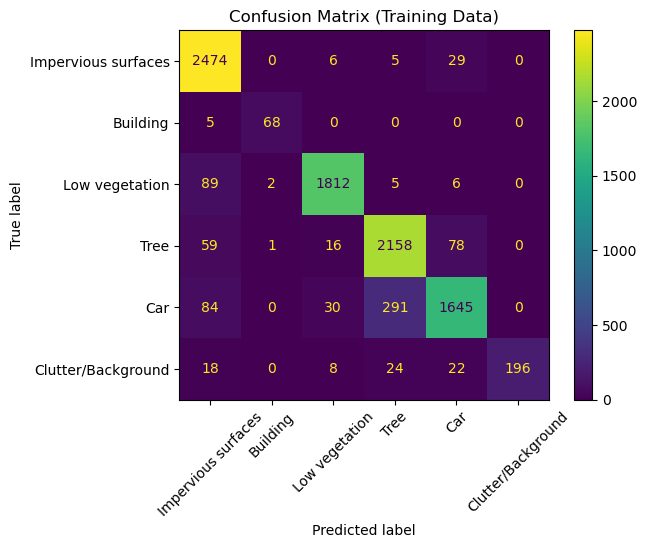

In [6]:
# YOUR CODE HERE
cm = confusion_matrix(y, pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(label_mapping.values())
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Training Data)")
plt.show()


### Task 3: Validation

In the previous examples, we began exploring the Random Forest classifier. However, the evaluation results are only of limited significance because the classifier has already seen all the data during training.
For this reason, the evaluation in the following steps will be performed on tile `5_11`, which is unknown to the classifier. When the following cell is executed, the corresponding data will be imported and preprocessed.

**Note:** It is just the usual import, nothing to do here.

SLIC Segmentation - Accuracy: 88.05%
Number of segments: 8739


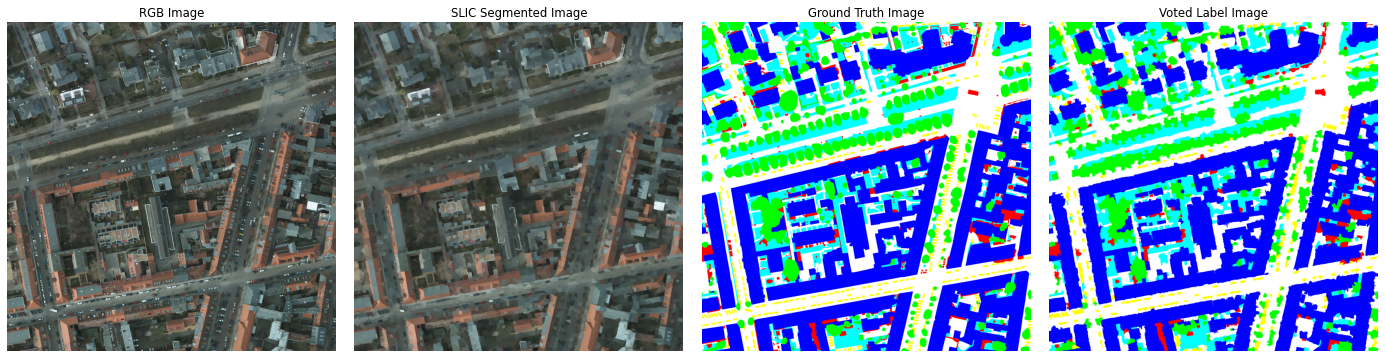

In [7]:
valid_dsm_filename = f"{data_path}/1_DSM_normalisation/dsm_potsdam_0{valid_tile_name}_normalized_lastools.jpg"
valid_rgb_filename = f"{data_path}/2_Ortho_RGB/top_potsdam_{valid_tile_name}_RGB.tif"
valid_rgbir_filename = f"{data_path}/4_Ortho_RGBIR/top_potsdam_{valid_tile_name}_RGBIR.tif"
valid_gt_filename = f"{data_path}/5_Labels_all/top_potsdam_{valid_tile_name}_label.tif"

valid_img_rgb = io.imread(valid_rgb_filename)
valid_img_ir  = io.imread(valid_rgbir_filename)[...,3]
valid_dsm     = io.imread(valid_dsm_filename)
valid_img_gt  = io.imread(valid_gt_filename)

valid_img_rgb = rescale(valid_img_rgb, (0.5,0.5,1), order = 1, preserve_range=True).astype(np.uint8)
valid_img_ir  = rescale(valid_img_ir,  (0.5),       order = 1, preserve_range=True).astype(np.uint8)
valid_dsm     = rescale(valid_dsm,     (0.5),       order = 0, preserve_range=True).astype(np.uint8)
valid_img_gt  = rescale(valid_img_gt,  (0.5,0.5,1), order = 0, preserve_range=True).astype(np.uint8)

# SLIC segmentation
valid_img_mask = slic_segmentation(valid_img_rgb, num_segments=10000, compactness=11)
# calculate image with mean value of each segment and featurevector based on RGB image
valid_img_segments, valid_feature_vectors = mean_segments(valid_img_rgb, valid_img_mask)
# calculate image with label of each segment and labelvector based on majority voting using the groundtruth image
valid_img_labels, valid_label_vectors = majority_vote_segments(valid_img_mask, rgb2index(valid_img_gt, label_def))
print(f"SLIC Segmentation - Accuracy: {np.mean(valid_img_labels == rgb2index(valid_img_gt, label_def))*100:.2f}%")
print(f"Number of segments: {len(np.unique(valid_img_mask))}")

valid_X = valid_feature_vectors
valid_y = valid_label_vectors
                                    
fig, axs = plt.subplots(1, 4, figsize=(20, 5), dpi=70)
axs[0].imshow(valid_img_rgb)
axs[0].set_title("RGB Image")
axs[0].axis("off")

axs[1].imshow(valid_img_segments)  # Display only the RGB channels
axs[1].set_title("SLIC Segmented Image")
axs[1].axis("off")

axs[2].imshow(valid_img_gt)
axs[2].set_title("Ground Truth Image")
axs[2].axis("off")

axs[3].imshow(index2rgb(valid_img_labels, label_def))
axs[3].set_title("Voted Label Image")
axs[3].axis("off")

plt.tight_layout()
plt.show()

### Task 3.1: Validate the Random Forest Classifier
Run the evaluation function with the Random forest Classifier `rfc` that was trained on tile `5_10` with the newly imported `valid_X` and `valid_y`.

**Note:** Yes, again a simple task.

**Result:** Save the results to `valid_acc` and `valid_pred_labels`.

In [ ]:
# YOUR CODE HERE
valid_acc, valid_pred_labels = evaluate_rfc(rfc, valid_X, valid_y)

print(f"Accuracy on validation data: {valid_acc:.2f}")

In [ ]:
### Do not change this cell - required for autograding


**3. Question:** When examining the given parameter combination, what could explain the relatively poor classification results?

The relatively poor classification performance can be explained by the chosen parameter combination and feature representation. The Random Forest was trained on a single tile using only simple segment-level RGB mean features, which do not generalize well to unseen validation data with different illumination and scene characteristics. In addition, the trees were grown without a depth limit, leading to overfitting on the training data. Class ambiguity between visually similar classes such as low vegetation and trees further degrades the validation accuracy.


### Task 3: Hyperparameter tuning

Now we want to check whether the number of trees and the depth of trees has a (significant) impact on the classification accuracy. Since the Random Forest training is very fast (less than a second!), we can afford to train and evaluate a lot of times (up to 400 and still below 5 minutes with default settings). Therefore, we will do a Hyperparameter search with brute force by sampling the hyperparameters on a regular grid. With each training of hyperparameter set, we need to evaluate against the unseen validation data. To keep track of the result, we store the accuracy in a matrix. You need to choose useful hyperparameter ranges for `n_estimators_values` and `max_depth_values`. Then fill in the training and evaluation inside of the loop.

**Note:** Do not safe the predicted labels of the evaluation each time to safe memory space. Do not change the variable names.

**Result:** You will be given points based on the highest value in `accuracy_val_matrix`. 1 Point for >55%, 2 Points for >57%, 3 Points for >59%, 4 Points for >60%.

Hyperparameter search took 0.3 seconds


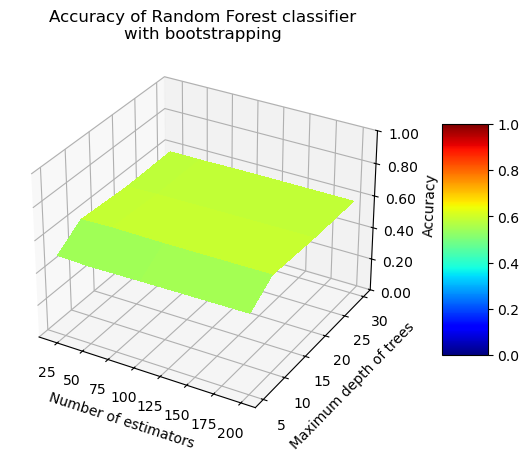

In [10]:
# TO-DO
# use meaningfull parameters 
bootstrap_values = [True, False]
n_estimators_values = np.array([20, 50, 100, 200], dtype=np.uint16)
max_depth_values = np.array([5, 10, 20, 30], dtype=np.uint8)
# initialise the matrox in which we will store the accuracy results
accuracy_val_matrix = np.zeros((len(bootstrap_values), len(n_estimators_values), len(max_depth_values)))

start = time()
for i, bs in enumerate(bootstrap_values):
    for j, n_e in enumerate(n_estimators_values):
        for k, m_d in enumerate(max_depth_values):
            # YOUR CODE HERE
            start = time()
for i, bs in enumerate(bootstrap_values):
    for j, n_e in enumerate(n_estimators_values):
        for k, m_d in enumerate(max_depth_values):

            rfc_tmp = get_trained_rfc(
                X, y,
                bootstrap=bs,
                n_estimators=n_e,
                max_depth=m_d,
                random_state=42
            )

            acc_tmp, _ = evaluate_rfc(rfc_tmp, valid_X, valid_y)

            # IMPORTANT: store in correct orientation
            accuracy_val_matrix[i, k, j] = acc_tmp
end = time()

print(f"Hyperparameter search took {((end-start)/60):.1f} seconds")

### Do not change the code below, only plotting results
fig, ax = plt.subplots(figsize=(12,5),subplot_kw={"projection": "3d"})
# Mesh data
n_estimators_axis, max_depth_axis = np.meshgrid(n_estimators_values, max_depth_values)
# Plot the cost landscape.
surf = ax.plot_surface(n_estimators_axis, max_depth_axis, accuracy_val_matrix[0,...] , cmap='jet',
                       linewidth=0, antialiased=False, vmin=0, vmax=1)
# Customize the z axis.
ax.set_zlim(0, 1)
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')
# Set labels on axis
ax.set_xlabel('Number of estimators')
ax.set_ylabel('Maximum depth of trees')
ax.set_zlabel('Accuracy')
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.6, aspect=5,)
plt.title('Accuracy of Random Forest classifier\nwith bootstrapping')
plt.show()

**4. Question:** Looking at the plot, does the number of trees (estimators) have a significant impact on your classification performance? Please explain why.

Based on the plot, the number of trees does not have a significant impact on the classification performance beyond a certain point. Increasing the number of estimators slightly improves stability and accuracy at first, but the performance quickly saturates. After approximately 50–100 trees, adding more trees does not lead to noticeable accuracy gains, as the Random Forest has already converged.


**5. Question:** Looking at the plot, does the depth of trees have a significant impact on your classification performance? Please explain why.

Yes, the depth of the trees has a significant impact on the classification performance. Very shallow trees underfit the data and lead to lower accuracy, while increasing the tree depth substantially improves performance. However, beyond a moderate depth, the accuracy gain becomes marginal, as very deep trees tend to overfit and do not generalize better to the validation data.


#### Task 3.1
Now we look up the parameters that gave the highest accurcy in our hyperparameter search and train a final model with those parameters.

**Note:** Use `np.argmax` and `np.unravel_index` to find the indice of the highest parameters.

**Result:** Store the Random Forest Classifier in a variable called `final_rfc`, the accurcay score in `accuracy_val` and the predicted labels in  `pred_labels`

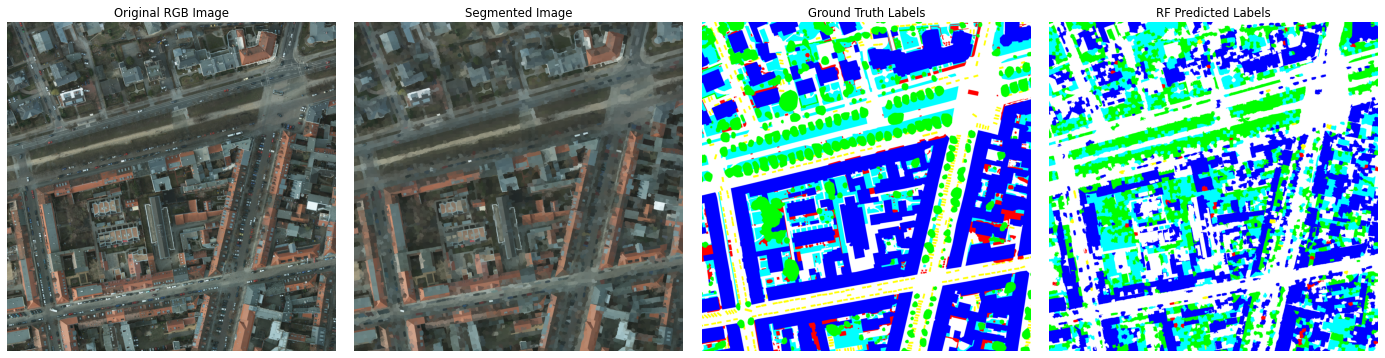

In [11]:
### find the best performing hyperparameter set and do the training and evaluation again
# YOUR CODE HERE
# find the best performing hyperparameter set
best_idx = np.unravel_index(
    np.argmax(accuracy_val_matrix),
    accuracy_val_matrix.shape
)

best_bs_idx, best_md_idx, best_ne_idx = best_idx

best_bootstrap = bootstrap_values[best_bs_idx]
best_max_depth = max_depth_values[best_md_idx]
best_n_estimators = n_estimators_values[best_ne_idx]

# train final model with best hyperparameters
final_rfc = get_trained_rfc(
    X, y,
    bootstrap=best_bootstrap,
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=42
)

# evaluate final model on validation data
accuracy_val, pred_labels = evaluate_rfc(
    final_rfc,
    valid_X,
    valid_y
)


### Do not change the code below - plotting only
def visualize_labels_on_segments(labels, mask):
    """
    Vectorized version: Map label predictions back to an image shape using segment IDs.
    """
    labels = np.asarray(labels)
    # Assumes that segment IDs in `segments` start from 0 and are contiguous
    return labels[mask]

# Map predicted labels to image
img_pred_labels = visualize_labels_on_segments(pred_labels, valid_img_mask)

# Plot everything
fig, axs = plt.subplots(1, 4, figsize=(20, 5), dpi=70)

axs[0].imshow(valid_img_rgb)
axs[0].set_title("Original RGB Image")
axs[0].axis("off")

axs[1].imshow(valid_img_segments, cmap='nipy_spectral')
axs[1].set_title("Segmented Image")
axs[1].axis("off")

axs[2].imshow(valid_img_gt)
axs[2].set_title("Ground Truth Labels")
axs[2].axis("off")

axs[3].imshow(index2rgb(img_pred_labels, label_def))
axs[3].set_title("RF Predicted Labels")
axs[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
### Do not change this cell - required for autograding


In [ ]:
### Do not change this cell - required for autograding


In [ ]:
### Do not change this cell - required for autograding


In [ ]:
### Do not change this cell - required for autograding


**6. Question:** When examining the given parameter combination, what could explain the relatively poor classification results?

The relatively poor classification performance can be explained by limited generalization of the model to unseen data. The Random Forest was trained on a single tile, while the validation tile contains different spatial patterns, illumination conditions, and class distributions. In addition, the feature representation is based on simple mean RGB values of segments, which may not be sufficient to reliably separate visually similar classes such as low vegetation and trees. This results in confusion between classes and reduced validation accuracy.


#### Task 2.4: Performance Evaluation (6 Points)

To get a final, unbiased evaluation of the performance, we need to test the Random Forest classifier on data that was not used during training. Since we used the validation set to tune our parameters, we can not use the validation set for an unbiased evaluation. Therefore, we load the test tile `5_12` in the following cell.

**Note:** Nothing to do here.

SLIC Segmentation - Accuracy: 91.05%
Number of segments: 8574


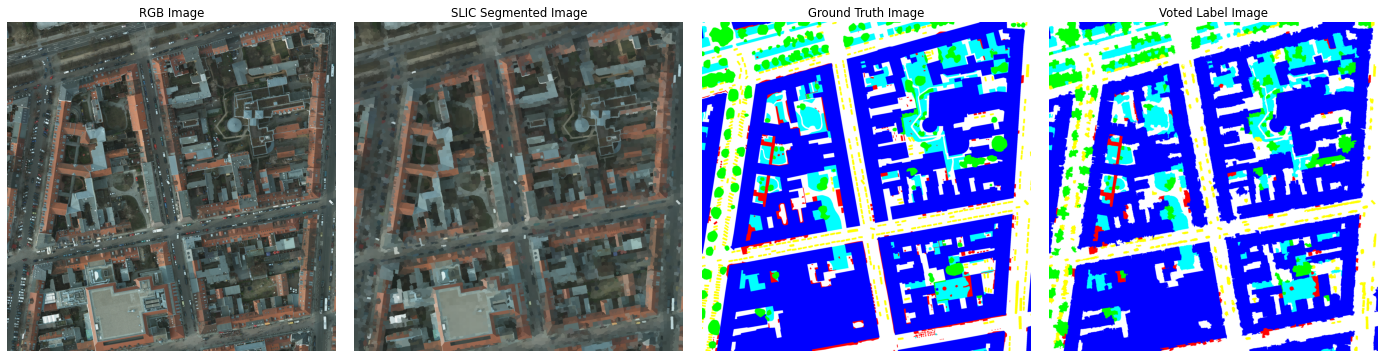

In [12]:
test_dsm_filename = f"{data_path}/1_DSM_normalisation/dsm_potsdam_0{test_tile_name}_normalized_lastools.jpg"
test_rgb_filename = f"{data_path}/2_Ortho_RGB/top_potsdam_{test_tile_name}_RGB.tif"
test_rgbir_filename = f"{data_path}/4_Ortho_RGBIR/top_potsdam_{test_tile_name}_RGBIR.tif"
test_gt_filename = f"{data_path}/5_Labels_all/top_potsdam_{test_tile_name}_label.tif"

test_img_rgb = io.imread(test_rgb_filename)
test_img_ir  = io.imread(test_rgbir_filename)[...,3]
test_dsm     = io.imread(test_dsm_filename)
test_img_gt  = io.imread(test_gt_filename)

test_img_rgb = rescale(test_img_rgb, (0.5,0.5,1), order = 1, preserve_range=True).astype(np.uint8)
test_img_ir  = rescale(test_img_ir,  (0.5),       order = 1, preserve_range=True).astype(np.uint8)
test_dsm     = rescale(test_dsm,     (0.5),       order = 0, preserve_range=True).astype(np.uint8)
test_img_gt  = rescale(test_img_gt,  (0.5,0.5,1), order = 0, preserve_range=True).astype(np.uint8)

# SLIC segmentation
test_img_mask = slic_segmentation(test_img_rgb, num_segments=10000, compactness=11)
# calculate image with mean value of each segment and featurevector based on RGB image
test_img_segments, test_feature_vectors = mean_segments(test_img_rgb, test_img_mask)
# calculate image with label of each segment and labelvector based on majority voting using the groundtruth image
test_img_labels, test_label_vectors = majority_vote_segments(test_img_mask, rgb2index(test_img_gt, label_def))
print(f"SLIC Segmentation - Accuracy: {np.mean(test_img_labels == rgb2index(test_img_gt, label_def))*100:.2f}%")
print(f"Number of segments: {len(np.unique(test_img_mask))}")

test_X = test_feature_vectors
test_y = test_label_vectors
                                    
fig, axs = plt.subplots(1, 4, figsize=(20, 5), dpi=70)
axs[0].imshow(test_img_rgb)
axs[0].set_title("RGB Image")
axs[0].axis("off")

axs[1].imshow(test_img_segments)  # Display only the RGB channels
axs[1].set_title("SLIC Segmented Image")
axs[1].axis("off")

axs[2].imshow(test_img_gt)
axs[2].set_title("Ground Truth Image")
axs[2].axis("off")

axs[3].imshow(index2rgb(test_img_labels, label_def))
axs[3].set_title("Voted Label Image")
axs[3].axis("off")

plt.tight_layout()
plt.show()


#### Better Metrics
Up to this point, the evaluation of the classifier has been done based solely on accuracy. While accuracy is a useful metric for initial parameter tuning and early performance analysis, it only provides limited insight into how suitable a classifier is for a specific task. For example, if a potential client needs to reliably identify the locations of trees in order to water them during dry months, the classifier must be particularly accurate in detecting trees.

To evaluate this more thoroughly, you will now create a confusion matrix. Please also calculate the `recall` and `precision` (micro average).

**Note:** Use the `confusion_matrix()` function from the `sklearn.metrics` library. For better visualization, use the `ConfusionMatrixDisplay()` class. The scores (recall/precision) can be calculated via the methods `precision_score()` and `recall_score()`. The evaluation should still be performed based on tile `5_11`.

**Result:** Save the Random Forest classifier used for the analysis in a variable named `rfc`, the resulting confusion matrix in a variable named `c_m` and the mapped names (according to the requirements of the `ConfusionMatrixDisplay()`) in a variable named `class_names`. 

Precision (macro): 0.493
Recall (macro): 0.408


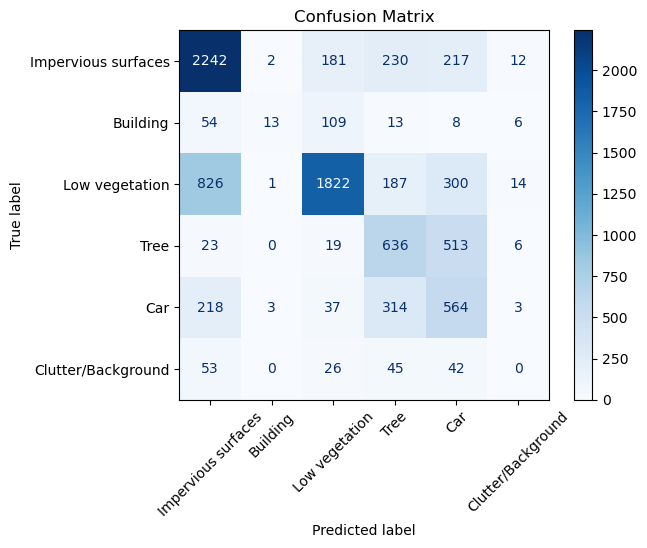

In [13]:
# YOUR CODE HERE
# use the trained random forest classifier
rfc = final_rfc

# predict labels on validation data (tile 5_11)
valid_pred_labels = rfc.predict(valid_X)

# confusion matrix
cm = confusion_matrix(valid_y, valid_pred_labels)

# class names for display
class_names = list(label_mapping.values())

# precision and recall (macro average)
precision = precision_score(valid_y, valid_pred_labels, average="macro")
recall = recall_score(valid_y, valid_pred_labels, average="macro")

### Do not change the code below - required for auto-grading
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

**7. Question:** Considering the question mentioned above — would the classifier be usable as part of a planning tool for tree irrigation? Explain your decision!

Given the observed performance, the classifier would not be sufficiently reliable as a standalone planning tool for tree irrigation. Although it can identify tree regions at a coarse level, the relatively low recall and confusion with low vegetation indicate that many trees would be missed or misclassified. For an operational irrigation planning system, higher recall for the tree class would be required to avoid excluding relevant tree locations.


**8. Question:** 
So far, only the performance of the classifier has been evaluated. How would the evaluation need to be adjusted if the entire pipeline — including segmentation — is to be assessed?

To assess the performance of the entire pipeline, the evaluation would need to be conducted at the pixel level rather than only at the segment or feature level. This would involve comparing the final predicted label image directly to the ground truth labels and computing pixel-based metrics such as per-class precision, recall, and Intersection over Union (IoU). In this way, errors introduced by both the segmentation and the classification stages would be jointly evaluated.


### Task 4: Review on semantic segmentation via Random Forests Classificators - Questions (11 Points)
This part is designed to reinforce your understanding and prepare you for the exam.

**9. Question:** 
Explain and discuss the differences between Bagging and Boosting.

Bagging (Bootstrap Aggregating) trains multiple models independently on different bootstrap samples of the training data and combines their predictions by averaging or voting. Its main goal is to reduce variance and improve stability. Boosting, in contrast, trains models sequentially, where each new model focuses on samples that were misclassified by previous models. Boosting primarily aims to reduce bias and can lead to stronger learners, but it is more sensitive to noise and outliers.


**10. Question:**
What is the main idea behind Random Forest?

The main idea behind Random Forest is to combine a large number of decision trees trained on different bootstrap samples and random subsets of features in order to reduce variance and improve generalization. The final prediction is obtained by aggregating the predictions of all trees, typically through majority voting or averaging.


**11. Question:**
What is controlled by the depth of the tree? Can you make it arbitrarily deep?

The depth of a tree controls the model complexity and the level of detail in the decision boundaries. Shallow trees may underfit the data, while very deep trees can overfit and memorize the training samples. Although a tree can technically be made arbitrarily deep, this is usually undesirable because it leads to poor generalization and increased sensitivity to noise.


**12. Question:**
What is controlled by the number of trees within a Random Forest?

The number of trees in a Random Forest controls the stability and variance reduction of the model. Increasing the number of trees generally improves performance by averaging out individual tree errors, but beyond a certain point the accuracy gain saturates while computational cost continues to increase.


**13. Question:**
What represents the entropy of a classification problem?

The entropy of a classification problem represents the amount of uncertainty or impurity in the class label distribution. It measures how mixed the classes are within a dataset, with higher entropy indicating greater uncertainty and lower entropy indicating a more pure or homogeneous class distribution.


**14. Question:**
Imagine you are given a two-class classification problem.
What happens to the entropy when the probability of one class becomes:
a Zero
b Equal to the probability of the other class

In a two-class classification problem, the entropy becomes zero when the probability of one class is zero and the other is one, because there is no uncertainty. When both classes have equal probability, the entropy reaches its maximum value, indicating maximum uncertainty.
